# Member 3 - Categorical Variable Encoding

**Student ID:** IT25100060 
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
One-Hot Encoding.

## Explanation
Many machine learning algorithms require numerical input. Therefore,
categorical variables need to be converted into numerical representations.

One-Hot Encoding creates binary indicator columns for categories without
introducing an artificial numerical order.

## Justification
The insurance dataset contains three categorical predictor variables:

- sex
- smoker
- region

These variables may contain useful information for predicting insurance
charges. Therefore, they should be encoded rather than removed.

One-Hot Encoding is appropriate because these categories do not have a natural
ordinal ranking.

## EDA
A boxplot of smoking status against insurance charges will be used to investigate
the relationship between a categorical feature and the target.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
categorical_columns = ["sex", "smoker", "region"]

for column in categorical_columns:

    print(f"\n{column.upper()}")

    print(df[column].value_counts())


SEX
sex
male      676
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


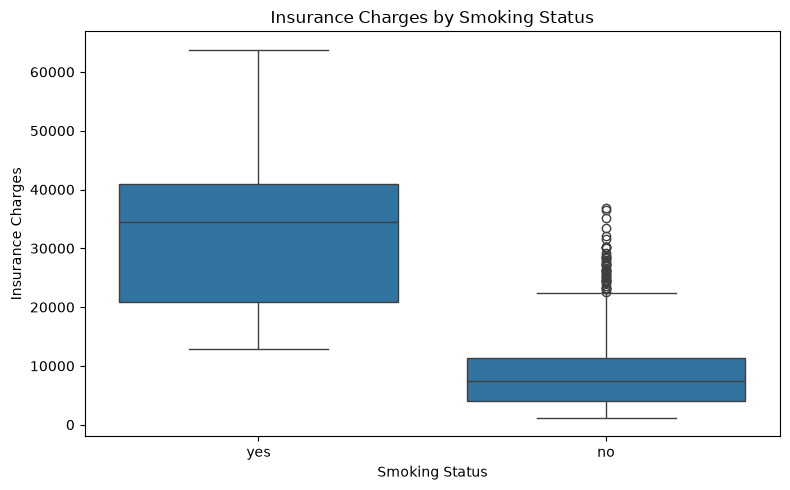

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member3_smoker_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
print("Shape Before Encoding:", df.shape)

df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

print("Shape After Encoding:", df_encoded.shape)

display(df_encoded.head())

Shape Before Encoding: (1338, 7)
Shape After Encoding: (1338, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [6]:
print("Columns After One-Hot Encoding:")

for column in df_encoded.columns:
    print(column)

print("\nRemaining Object Columns:")
print(
    df_encoded.select_dtypes(include="object").columns.tolist()
)

Columns After One-Hot Encoding:
age
bmi
children
charges
sex_male
smoker_yes
region_northwest
region_southeast
region_southwest

Remaining Object Columns:
[]


## EDA Interpretation

The boxplot shows a clear difference in insurance charges between smokers and
non-smokers. Smokers generally have considerably higher medical insurance
charges.

Therefore, smoking status contains useful information and should not be removed
from the dataset.

One-Hot Encoding converts categorical information into numerical features while
avoiding an incorrect ordinal relationship between categories.

In [7]:
df_encoded.to_csv(
    "../results/outputs/member3_encoded.csv",
    index=False
)

print("Member 3 preprocessing completed.")

Member 3 preprocessing completed.
